In [1]:
# Step 1: Import Necessary Libraries
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import image, plotting, masking, datasets
from nilearn.input_data import NiftiMasker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense

In [2]:
import os

def get_bold_file_paths(base_dir):
    control_subjects = []
    non_dyslexic_subjects = []
    control_ids = {11, 12, 13, 18, 19, 23, 24, 25, 26, 29, 30, 31, 32, 33, 34, 35, 36, 37, 40, 41}
    
    for sub_num in range(1, 43):  # Looping from sub-01 to sub-42
        sub_folder = f"sub-{sub_num:02d}"  # Format to ensure two-digit numbering
        #func_path = os.path.join(base_dir, sub_folder, "func")
        func_path = os.path.join(base_dir, sub_folder)
        
        if os.path.exists(func_path):
            for file in os.listdir(func_path):
                if file.endswith(("task-morphosem_run-01_bold.nii.gz","task-morphosem_run-02_bold.nii.gz","task-morphosem_run-03_bold.nii.gz","task-morphosem_run-04_bold.nii.gz")):
                    file_path = os.path.join(func_path, file)
                    if sub_num in control_ids:
                        control_subjects.append(file_path)
                    else:
                        non_dyslexic_subjects.append(file_path)
    
    return control_subjects, non_dyslexic_subjects

# Set the base directory
#base_directory = r"D:\project_7th_sem\ds004786-download"
base_directory = r"D:\myResearch\Dataset01_MorphoSem"

# Get the list of file paths
control_subjects, non_dyslexic_subjects = get_bold_file_paths(base_directory)

# Print the lists
print("Control Subjects:")
for i,path in enumerate(control_subjects):
    print(path)

print("\nNon-Dyslexic Subjects:")
for j,path in enumerate(non_dyslexic_subjects):
    print(path)

print (i)
print (j)

print(len(control_subjects),len(non_dyslexic_subjects))

Control Subjects:
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-04_bold.nii.g

[get_dataset_dir] Dataset found in C:\Users\utpal\nilearn_data\fsl

0: Background
1: Frontal Pole
2: Insular Cortex
3: Superior Frontal Gyrus
4: Middle Frontal Gyrus
5: Inferior Frontal Gyrus, pars triangularis
6: Inferior Frontal Gyrus, pars opercularis
7: Precentral Gyrus
8: Temporal Pole
9: Superior Temporal Gyrus, anterior division
10: Superior Temporal Gyrus, posterior division
11: Middle Temporal Gyrus, anterior division
12: Middle Temporal Gyrus, posterior division
13: Middle Temporal Gyrus, temporooccipital part
14: Inferior Temporal Gyrus, anterior division
15: Inferior Temporal Gyrus, posterior division
16: Inferior Temporal Gyrus, temporooccipital part
17: Postcentral Gyrus
18: Superior Parietal Lobule
19: Supramarginal Gyrus, anterior division
20: Supramarginal Gyrus, posterior division
21: Angular Gyrus
22: Lateral Occipital Cortex, superior division
23: Lateral Occipital Cortex, inferior division
24: Intracalcarine Cortex
25: Frontal Medial Cortex
26: Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
27: Subcallosal Cort

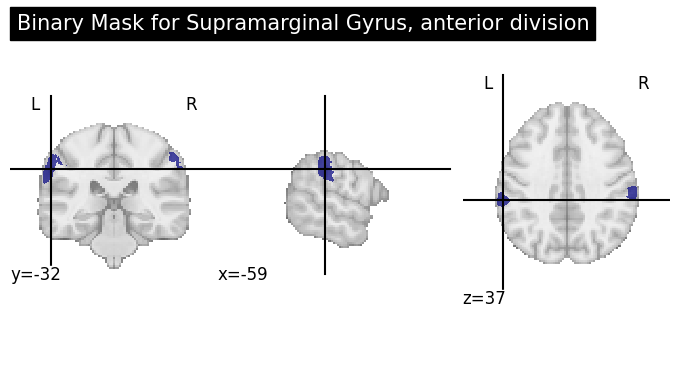

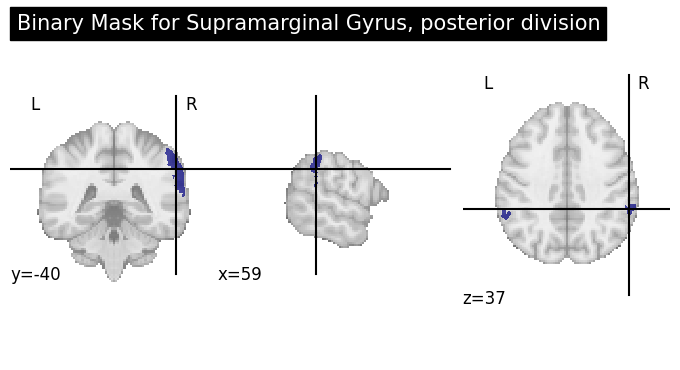

In [3]:
# Step 2: Load the Harvard-Oxford atlas and select a specific region
from nilearn.image import math_img

# Load the Harvard-Oxford cortical atlas (probabilistic map)
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-1mm')
atlas_img = atlas['maps']
atlas_labels = atlas['labels']

# Print available region labels to confirm the correct region index
for idx, label in enumerate(atlas_labels):
    print(f"{idx}: {label}")

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars triangularis)
region_name1 = "Supramarginal Gyrus, anterior division"  # Region of Interest
region_idx1 = atlas_labels.index(region_name1)  # Find index for Inferior Frontal Gyrus, pars triangularis
# Create a binary mask for the selected region
binary_mask1 = math_img(f"img == {region_idx1}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask1, title=f"Binary Mask for {region_name1}", display_mode='ortho')
plotting.show()

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars opercularis)
region_name2 = "Supramarginal Gyrus, posterior division"  # Region of Interest
region_idx2 = atlas_labels.index(region_name2)  # Find index for Inferior Frontal Gyrus, pars opercularis 
# Create a binary mask for the selected region
binary_mask2 = math_img(f"img == {region_idx2}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask2, title=f"Binary Mask for {region_name2}", display_mode='ortho')
plotting.show()


## Extracting all the ROIs **(WITHOUT MEAN)**

In [4]:
# Initialize NiftiMasker
roi_masker1 = NiftiMasker(mask_img=binary_mask1, standardize=True)

# Aggregate data across time for each control subject
control_data1 = [roi_masker1.fit_transform(nib.load(subject)) for subject in control_subjects]

# Aggregate data across time for each non-dyslexic subject
non_dyslexic_data1 = [roi_masker1.fit_transform(nib.load(subject)) for subject in non_dyslexic_subjects]

# Initialize NiftiMasker
roi_masker2 = NiftiMasker(mask_img=binary_mask2, standardize=True)

# Aggregate data across time for each control subject
control_data2 = [roi_masker2.fit_transform(nib.load(subject)) for subject in control_subjects]

# Aggregate data across time for each non-dyslexic subject
non_dyslexic_data2 = [roi_masker2.fit_transform(nib.load(subject)) for subject in non_dyslexic_subjects]


D:\Aanaconda3\envs\env_sih\lib\site-packages\nilearn\maskers\nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images

D:\Aanaconda3\envs\env_sih\lib\site-packages\joblib\memory.py:312: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)
D:\Aanaconda3\envs\env_sih\lib\site-packages\nilearn\maskers\nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images

D:\Aanaconda3\envs\env_sih\lib\site-packages\joblib\memory.py:312: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)
D:\Aanaconda3\envs\env_sih\lib\site-packages\nilearn\maskers\nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


...

[NiftiMasker.wrapped] Resampling images

D:\Aanaconda3\envs\env_sih\lib\site-packages\joblib\memory.py:312: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)
D:\Aanaconda3\envs\env_sih\lib\site-packages\nilearn\maskers\nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images

D:\Aanaconda3\envs\env_sih\lib\site-packages\joblib\memory.py:312: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)
D:\Aanaconda3\envs\env_sih\lib\site-packages\nilearn\maskers\nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images

## Saving all the ROIs **[Without Mean]**

##### To save the ROIs we have to make sure that all the data are of the same dimensions else it won't save on Disk.

##### <b>Checking the dimensions for control_data1 and saving on Disk</b>

In [5]:
row,col=control_data1[0].shape
#print("control_data1",row,col)
cd1=[]
#Checking if there is uneven dimensions
for i in range(len(control_data1)):
    r,c=control_data1[i].shape
    if (r!=row or c!=col):
        print("control_data1",i,r,c,"<<--HERE")
        cd1.append(i)
#If there is uneven dimensions, then correcting the dimensions
if(len(cd1)!=0):
    print("control_data1 -< Problem in index no >--",cd1)
    row,col=control_data1[0].shape
    control1=[]
    for i in range(len(control_data1)):
        r,c=control_data1[i].shape
        if (row>r): ##Correcting the row dimension
            add1=np.mean(control_data1[i], axis = 0)
            add1=add1.reshape(1,add1.shape[0])
            #temp=np.empty((0, row*col), np.float32)
            temp=control_data1[i]
            for j in range(row-r):
                temp=np.append(temp, add1, axis=0)
            control1.append(temp)
        elif (col>c): ##Correcting the column dimension
            temp=np.empty((0, row*col), np.float32)
            for j in range(control_data1[0].shape[0]):
                add1=np.pad(control_data1[i][j], (0, col-c), 'mean')
                temp=np.append(temp, add1, axis=0)
            control1.append(temp)
        else:
            control1.append(control_data1[i])

if(len(cd1)!=0):
    print("control_data1",len(control_data1))
    print("control1",len(control1))
    print("Before")
    for i in range(len(cd1)):
        print("At Index",cd1[i],control_data1[cd1[i]].shape)
    print("After")
    for i in range(len(cd1)):
        print("At Index",cd1[i],control1[cd1[i]].shape)
    np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_anterior_division.npz", control_data1=control1)
    print("Corrected data is saved on Disk as np file")
else:
    print("No corrections required, all dimensions are same")
    np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_anterior_division.npz", control_data1=control_data1)
    print("Data is saved on Disk as np file")

control_data1 23 256 5153 <<--HERE
control_data1 -< Problem in index no >-- [23]
control_data1 80
control1 80
Before
At Index 23 (256, 5153)
After
At Index 23 (274, 5153)
Corrected data is saved on Disk as np file


##### <b>Checking the dimensions for non_dyslexic_data1 and saving on Disk</b>

In [6]:
row,col=non_dyslexic_data1[0].shape
#print("non_dyslexic_data1",row,col)
cd1=[]
#Checking if there is uneven dimensions
for i in range(len(non_dyslexic_data1)):
    r,c=non_dyslexic_data1[i].shape
    if (r!=row or c!=col):
        print("non_dyslexic_data1",i,r,c,"<<--HERE")
        cd1.append(i)
#If there is uneven dimensions, then correcting the dimensions
if(len(cd1)!=0):
    print("non_dyslexic_data1 -< Problem in index no >--",cd1)
    row,col=non_dyslexic_data1[0].shape
    non_dyslexic1=[]
    for i in range(len(non_dyslexic_data1)):
        r,c=non_dyslexic_data1[i].shape
        if (row>r): ##Correcting the row dimension
            add1=np.mean(non_dyslexic_data1[i], axis = 0)
            add1=add1.reshape(1,add1.shape[0])
            #temp=np.empty((0, row*col), np.float32)
            temp=non_dyslexic_data1[i]
            for j in range(row-r):
                temp=np.append(temp, add1, axis=0)
            non_dyslexic1.append(temp)
        elif (col>c): ##Correcting the column dimension
            temp=np.empty((0, row*col), np.float32)
            for j in range(non_dyslexic_data1[0].shape[0]):
                add1=np.pad(non_dyslexic_data1[i][j], (0, col-c), 'mean')
                temp=np.append(temp, add1, axis=0)
            non_dyslexic1.append(temp)
        else:
            non_dyslexic1.append(non_dyslexic_data1[i])

if(len(cd1)!=0):
    print("non_dyslexic_data1",len(non_dyslexic_data1))
    print("non_dyslexic1",len(non_dyslexic1))
    print("Before")
    for i in range(len(cd1)):
        print("At Index",cd1[i],non_dyslexic_data1[cd1[i]].shape)
    print("After")
    for i in range(len(cd1)):
        print("At Index",cd1[i],non_dyslexic1[cd1[i]].shape)
    np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_anterior_division.npz", non_dyslexic_data1=non_dyslexic1)
    print("Corrected data is saved on Disk as np file")
else:
    print("No corrections required, all dimensions are same")
    np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_anterior_division.npz", non_dyslexic_data1=non_dyslexic_data1)
    print("Data is saved on Disk as np file")

No corrections required, all dimensions are same
Data is saved on Disk as np file


##### <b>Checking the dimensions for control_data2 and saving on Disk</b>

In [7]:
row,col=control_data2[0].shape
#print("control_data2",row,col)
cd1=[]
#Checking if there is uneven dimensions
for i in range(len(control_data2)):
    r,c=control_data2[i].shape
    if (r!=row or c!=col):
        print("control_data2",i,r,c,"<<--HERE")
        cd1.append(i)
#If there is uneven dimensions, then correcting the dimensions
if(len(cd1)!=0):
    print("control_data2 -< Problem in index no >--",cd1)
    row,col=control_data2[0].shape
    control2=[]
    for i in range(len(control_data2)):
        r,c=control_data2[i].shape
        if (row>r): ##Correcting the row dimension
            add1=np.mean(control_data2[i], axis = 0)
            add1=add1.reshape(1,add1.shape[0])
            #temp=np.empty((0, row*col), np.float32)
            temp=control_data2[i]
            for j in range(row-r):
                temp=np.append(temp, add1, axis=0)
            control2.append(temp)
        elif (col>c): ##Correcting the column dimension
            temp=np.empty((0, row*col), np.float32)
            for j in range(control_data2[0].shape[0]):
                add1=np.pad(control_data2[i][j], (0, col-c), 'mean')
                temp=np.append(temp, add1, axis=0)
            control2.append(temp)
        else:
            control2.append(control_data2[i])

if(len(cd1)!=0):
    print("control_data2",len(control_data2))
    print("control2",len(control2))
    print("Before")
    for i in range(len(cd1)):
        print("At Index",cd1[i],control_data2[cd1[i]].shape)
    print("After")
    for i in range(len(cd1)):
        print("At Index",cd1[i],control2[cd1[i]].shape)
    np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_posterior_division.npz", control_data2=control2)
    print("Corrected data is saved on Disk as np file")
else:
    print("No corrections required, all dimensions are same")
    np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_posterior_division.npz", control_data2=control_data2)
    print("Data is saved on Disk as np file")

control_data2 23 256 4273 <<--HERE
control_data2 -< Problem in index no >-- [23]
control_data2 80
control2 80
Before
At Index 23 (256, 4273)
After
At Index 23 (274, 4273)
Corrected data is saved on Disk as np file


##### <b>Checking the dimensions for non_dyslexic_data2 and saving on Disk</b>

In [8]:
row,col=non_dyslexic_data2[0].shape
#print("non_dyslexic_data2",row,col)
cd1=[]
#Checking if there is uneven dimensions
for i in range(len(non_dyslexic_data2)):
    r,c=non_dyslexic_data2[i].shape
    if (r!=row or c!=col):
        print("non_dyslexic_data2",i,r,c,"<<--HERE")
        cd1.append(i)
#If there is uneven dimensions, then correcting the dimensions
if(len(cd1)!=0):
    print("non_dyslexic_data2 -< Problem in index no >--",cd1)
    row,col=non_dyslexic_data2[0].shape
    non_dyslexic2=[]
    for i in range(len(non_dyslexic_data2)):
        r,c=non_dyslexic_data2[i].shape
        if (row>r): ##Correcting the row dimension
            add1=np.mean(non_dyslexic_data2[i], axis = 0)
            add1=add1.reshape(1,add1.shape[0])
            #temp=np.empty((0, row*col), np.float32)
            temp=non_dyslexic_data2[i]
            for j in range(row-r):
                temp=np.append(temp, add1, axis=0)
            non_dyslexic2.append(temp)
        elif (col>c): ##Correcting the column dimension
            temp=np.empty((0, row*col), np.float32)
            for j in range(non_dyslexic_data2[0].shape[0]):
                add1=np.pad(non_dyslexic_data2[i][j], (0, col-c), 'mean')
                temp=np.append(temp, add1, axis=0)
            non_dyslexic2.append(temp)
        else:
            non_dyslexic2.append(non_dyslexic_data2[i])

if(len(cd1)!=0):
    print("non_dyslexic_data2",len(non_dyslexic_data2))
    print("non_dyslexic2",len(non_dyslexic2))
    print("Before")
    for i in range(len(cd1)):
        print("At Index",cd1[i],non_dyslexic_data2[cd1[i]].shape)
    print("After")
    for i in range(len(cd1)):
        print("At Index",cd1[i],non_dyslexic2[cd1[i]].shape)
    np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_posterior_division.npz", non_dyslexic_data2=non_dyslexic2)
    print("Corrected data is saved on Disk as np file")
else:
    print("No corrections required, all dimensions are same")
    np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_posterior_division.npz", non_dyslexic_data2=non_dyslexic_data2)
    print("Data is saved on Disk as np file")

No corrections required, all dimensions are same
Data is saved on Disk as np file


## Till here all ROIs saved **[ Without MEAN ]**

#### Load all ROIs saved **[ Without MEAN ]**

In [9]:
####Loading all the saved dataset in np format.
cd1 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_anterior_division.npz")
ndd1 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_anterior_division.npz")
control_data1 = cd1["control_data1"]
non_dyslexic_data1=ndd1["non_dyslexic_data1"]
cd2 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_posterior_division.npz")
ndd2 = np.load("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_posterior_division.npz")
control_data2 = cd2["control_data2"]
non_dyslexic_data2=ndd2["non_dyslexic_data2"]
####
print()
print(len(control_data1))
print(len(non_dyslexic_data1))
print(len(control_data2))
print(len(non_dyslexic_data2))
print(control_data1[0].shape)
print(non_dyslexic_data1[0].shape)
print(control_data2[0].shape)
print(non_dyslexic_data2[0].shape)



80
80
80
80
(274, 5153)
(274, 5153)
(274, 4273)
(274, 4273)


## Extracting all the ROIs **(MEAN)**

In [10]:
# Initialize NiftiMasker
# roi_masker1 = NiftiMasker(mask_img=binary_mask1, standardize=True)

# Aggregate data across time for each control subject
# control_mean_data1 = [np.mean(roi_masker1.fit_transform(nib.load(subject)), axis=0) for subject in control_subjects]
control_mean_data1 = [np.mean(subject, axis=0) for subject in control_data1]

# # Aggregate data across time for each non-dyslexic subject
# non_dyslexic_mean_data1 = [np.mean(roi_masker1.fit_transform(nib.load(subject)), axis=0) for subject in non_dyslexic_subjects]
non_dyslexic_mean_data1 = [np.mean(subject, axis=0) for subject in non_dyslexic_data1]

# Initialize NiftiMasker
# roi_masker2 = NiftiMasker(mask_img=binary_mask2, standardize=True)

# Aggregate data across time for each control subject
# control_mean_data2 = [np.mean(roi_masker2.fit_transform(nib.load(subject)), axis=0) for subject in control_subjects]
control_mean_data2 = [np.mean(subject, axis=0) for subject in control_data2]

# Aggregate data across time for each non-dyslexic subject
# non_dyslexic_mean_data2 = [np.mean(roi_masker2.fit_transform(nib.load(subject)), axis=0) for subject in non_dyslexic_subjects]
non_dyslexic_mean_data2 = [np.mean(subject, axis=0) for subject in non_dyslexic_data2]


## Saving all the ROIs **-> Mean <-**

In [11]:
np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_mean_anterior_division.npz", control_mean_data1=control_mean_data1)
np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_mean_anterior_division.npz", non_dyslexic_mean_data1=non_dyslexic_mean_data1)
np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/control_mean_posterior_division.npz", control_mean_data2=control_mean_data2)
np.savez("../../Data_Mask-ROI/5-Supramarginal_Gyrus/non_dyslexic_mean_posterior_division.npz", non_dyslexic_mean_data2=non_dyslexic_mean_data2)
